Loading the Data

In [92]:
import pandas as pd
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

EDA

In [93]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [94]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [95]:
df.duplicated().sum()

np.int64(0)

In [96]:
df1 = df.copy()

In [97]:
df2 = df1.drop('DEATH_EVENT', axis=1)

In [98]:
df2.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8


In [99]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 28.2 KB


In [101]:
df2.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000


In [102]:
df2.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
      dtype='object')

In [103]:
numerical_cols = [
    'age',
    'creatinine_phosphokinase',
    'ejection_fraction',
    'platelets',
    'serum_creatinine',
    'serum_sodium'
]

categorical_cols = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking'
]

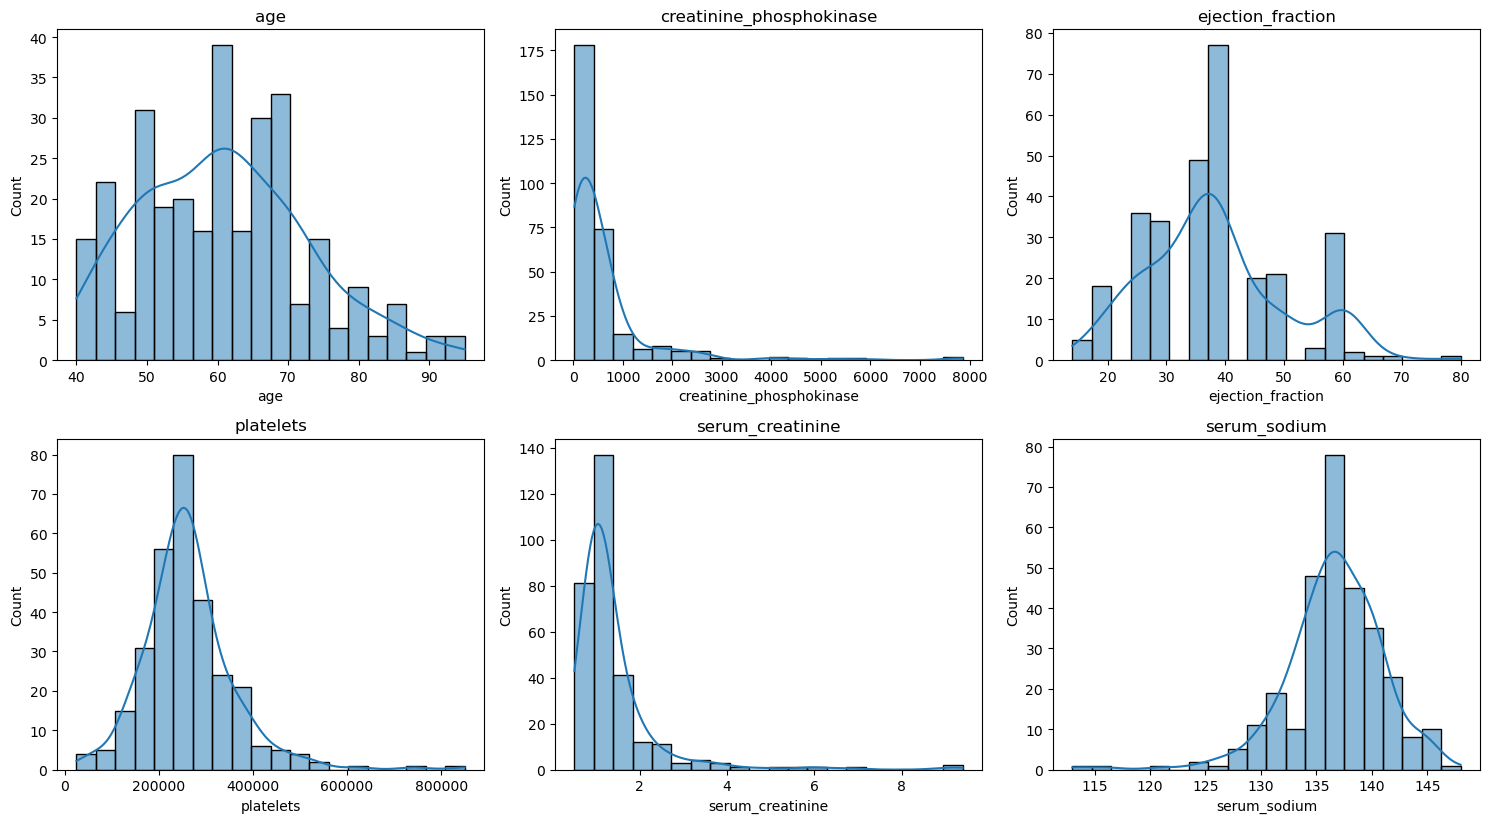

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(3,3, figsize=(15,12))

for ax, col in zip(axes.flatten(), numerical_cols):
    sns.histplot(df2[col], kde=True, bins=20, ax=ax)
    ax.set_title(col)
for ax in axes.flatten()[len(numerical_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

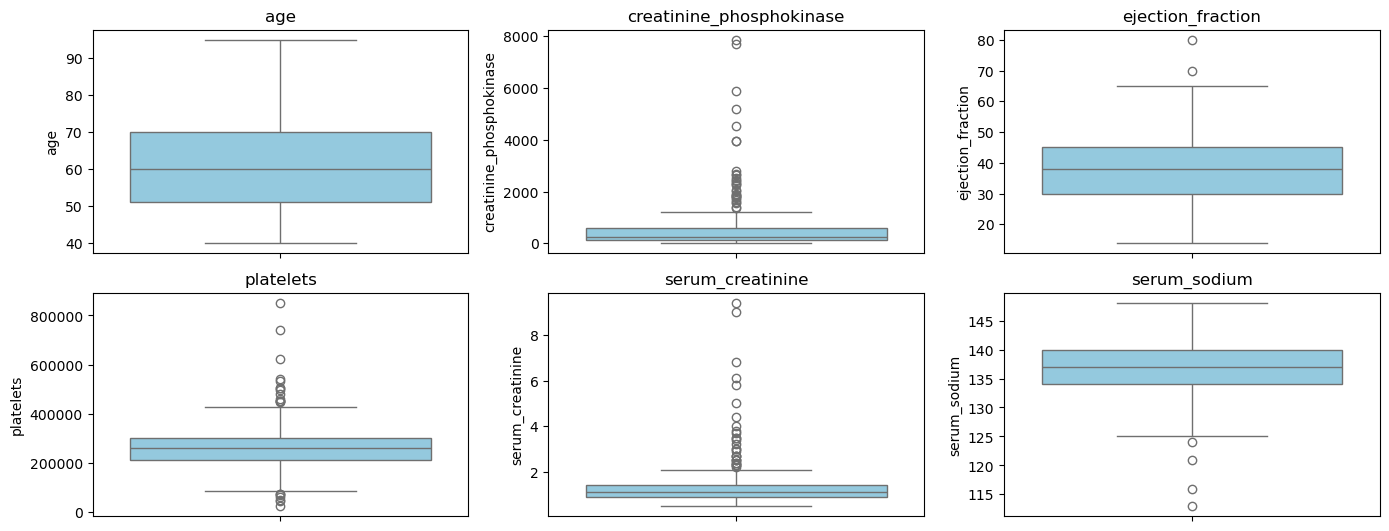

In [105]:
plt.figure(figsize=(14,8))

for i, col in enumerate(numerical_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df2[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

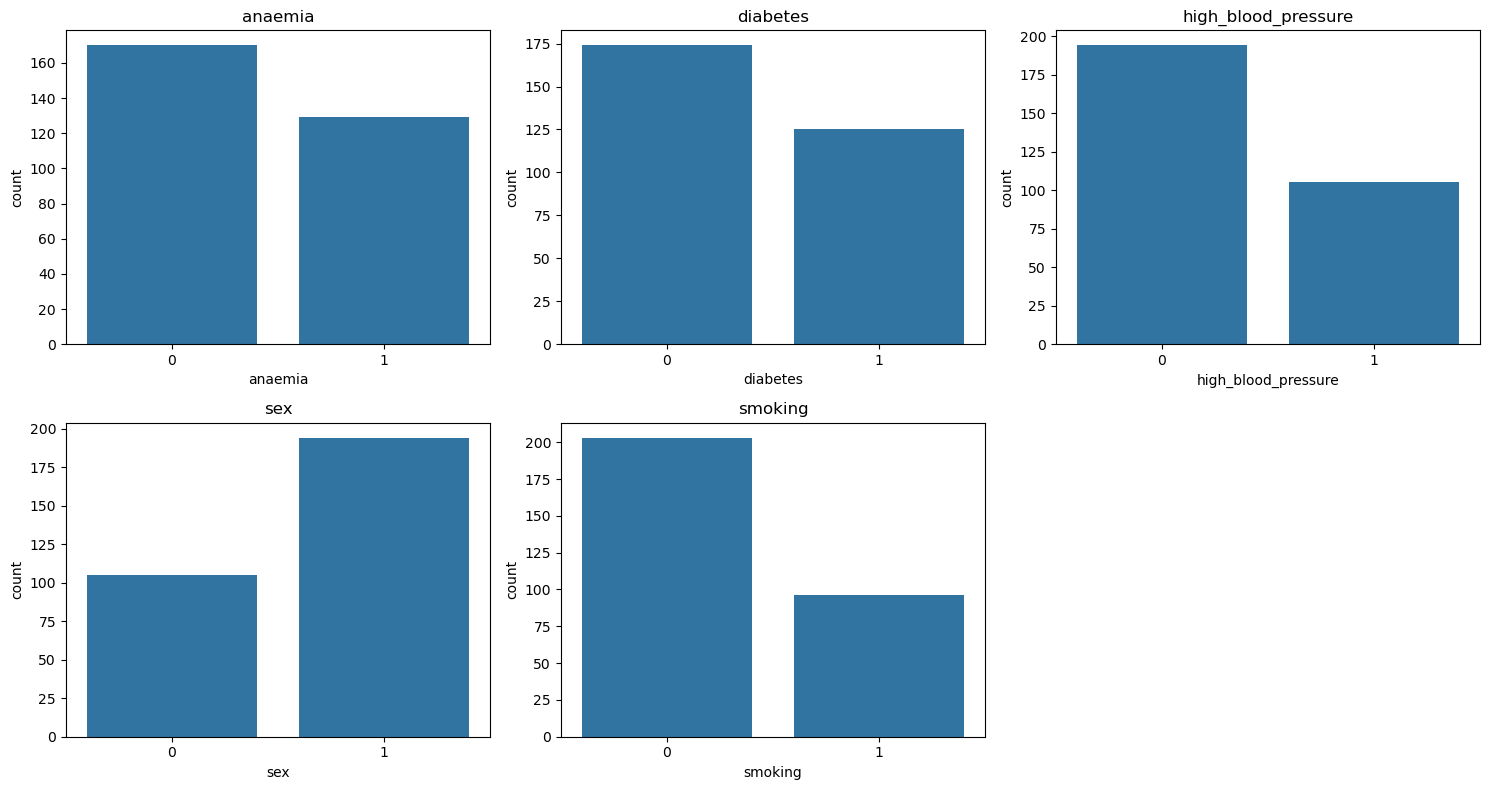

In [106]:
categorical_cols = [
    'anaemia',
    'diabetes',
    'high_blood_pressure',
    'sex',
    'smoking',
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))

for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=df2, x=col, ax=ax)
    ax.set_title(col)

fig.delaxes(axes.flatten()[-1])

plt.tight_layout()
plt.show()

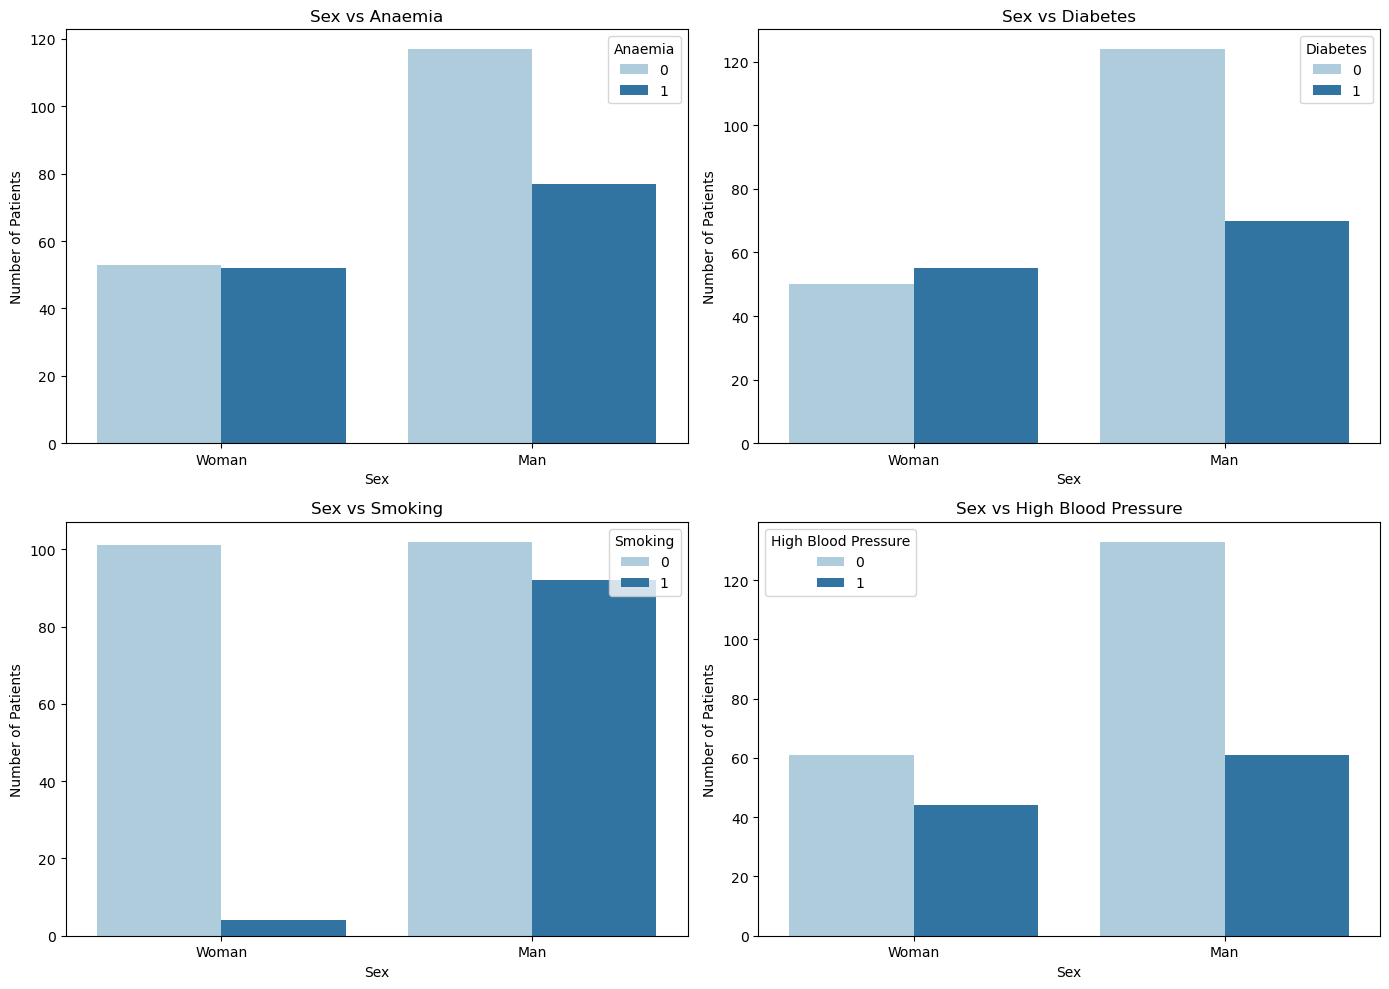

In [107]:
categorical_vars = ['anaemia', 'diabetes', 'smoking', 'high_blood_pressure']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, var in zip(axes, categorical_vars):
    sns.countplot(
        data=df2,
        x="sex",
        hue=var,
        ax=ax,
        palette="Paired"
    )

    ax.set_title(f"Sex vs {var.replace('_', ' ').title()}")
    ax.set_xlabel("Sex")
    ax.set_ylabel("Number of Patients")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Woman', 'Man']) 
    ax.legend(title=var.replace('_', ' ').title())

plt.tight_layout()
plt.show()

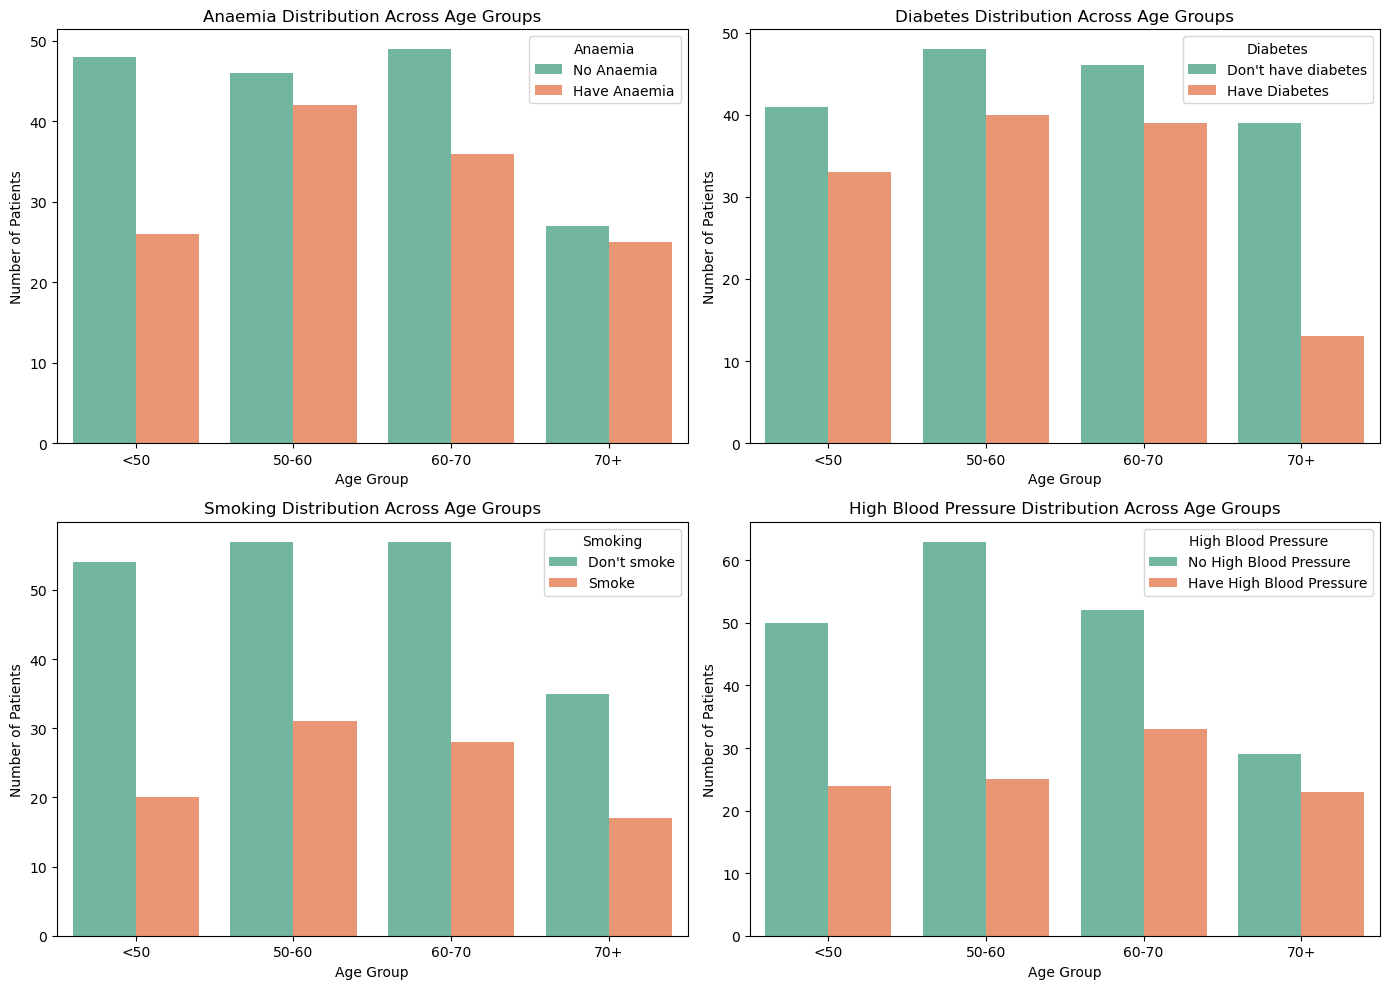

In [108]:
df2['age_group'] = pd.cut(
    df2['age'],
    bins=[35, 50, 60, 70, 100],
    labels=['<50', '50-60', '60-70', '70+']
)

df_plot = df2.copy()

df_plot['anaemia'] = df_plot['anaemia'].map({0: 'No Anaemia', 1: 'Have Anaemia'})
df_plot['diabetes'] = df_plot['diabetes'].map({0: "Don't have diabetes", 1: 'Have Diabetes'})
df_plot['smoking'] = df_plot['smoking'].map({0: "Don't smoke", 1: 'Smoke'})
df_plot['high_blood_pressure'] = df_plot['high_blood_pressure'].map({0: 'No High Blood Pressure', 1: 'Have High Blood Pressure'})

cat_features = ['anaemia', 'diabetes', 'smoking', 'high_blood_pressure']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, cat_features):

    order = sorted(df_plot[feature].unique(), key=lambda x: x.startswith("Have") or x == "Smoke")

    sns.countplot(
        data=df_plot,
        x='age_group',
        hue=feature,
        hue_order=order,
        palette=['#66c2a5', '#fc8d62'],
        ax=ax
    )

    ax.set(
        xlabel='Age Group',
        ylabel='Number of Patients',
        title=f"{feature.replace('_',' ').title()} Distribution Across Age Groups"
    )

    ax.legend(title=feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

Feature Analysis

In [109]:
X = df2.drop('age_group', axis=1)

In [110]:
X.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8


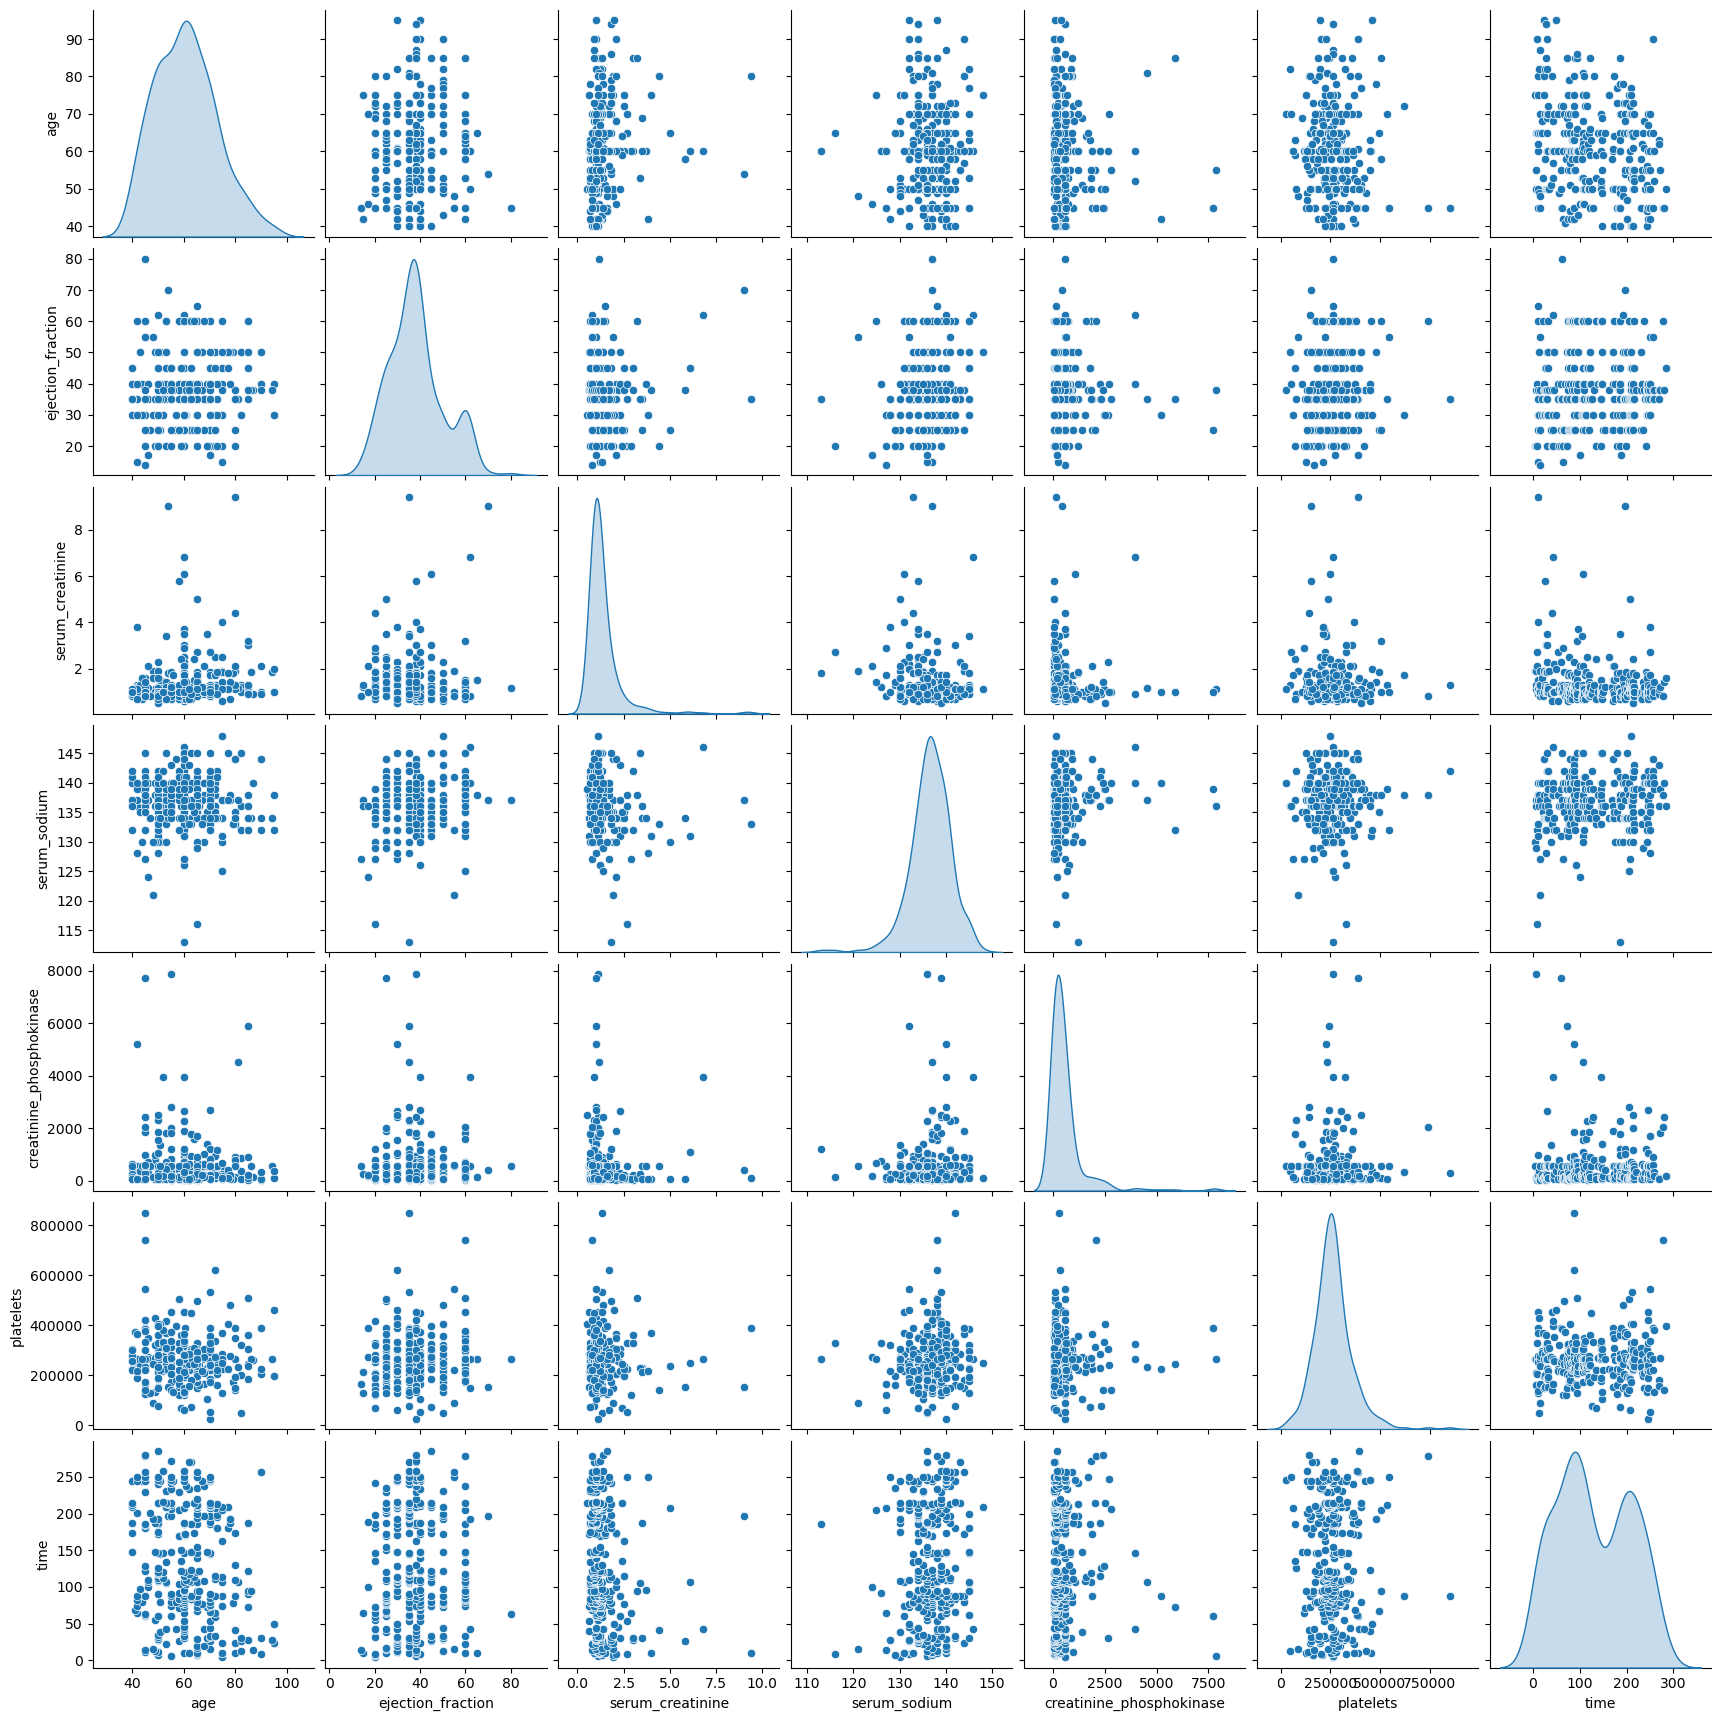

In [111]:
important = [
    'age',
    'ejection_fraction',
    'serum_creatinine',
    'serum_sodium',
    'creatinine_phosphokinase',
    'platelets',
    'time'

]

sns.pairplot(df2[important], diag_kind='kde')

plt.show()

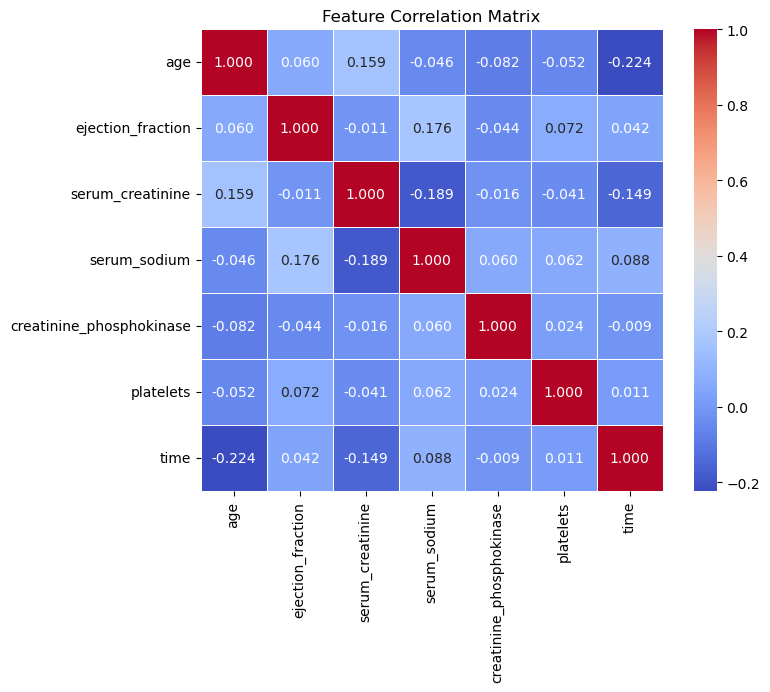

In [112]:
corr = df2[important].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.5,
    square=True
)

plt.title('Feature Correlation Matrix')
plt.show()

Clustering

In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

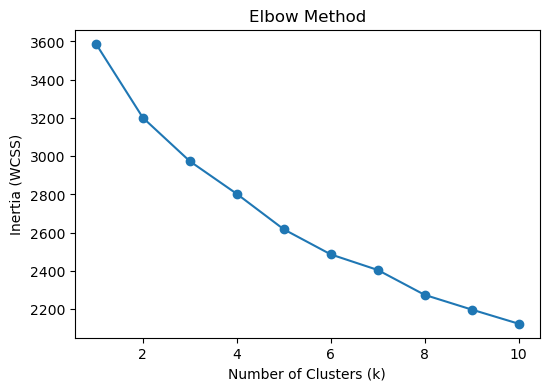

In [114]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.show()

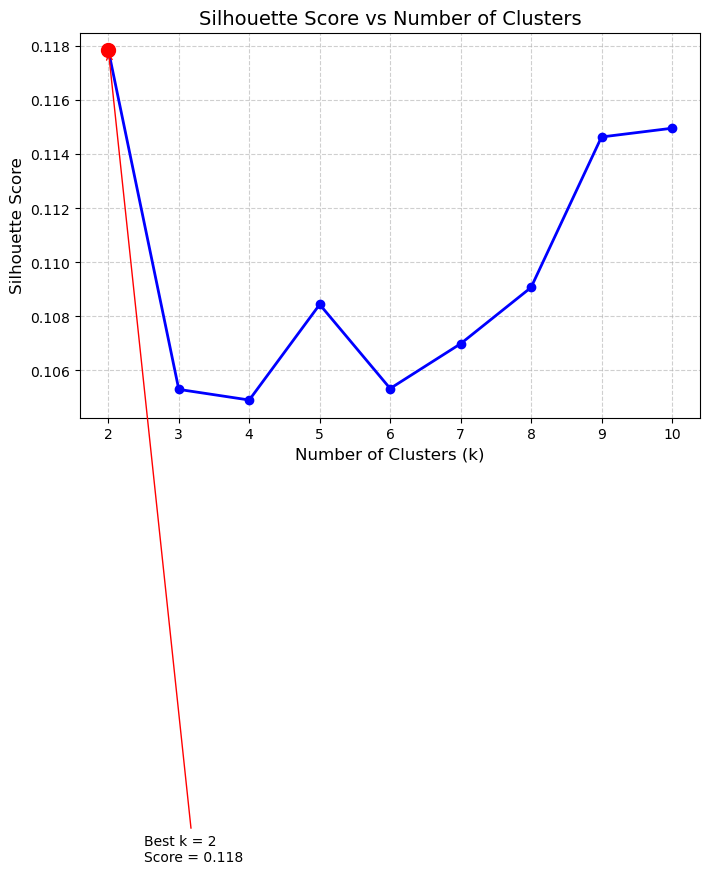

In [115]:
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linewidth=2, color='blue')
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score vs Number of Clusters", fontsize=14)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)

plt.scatter(best_k, best_score, color='red', s=100, zorder=5)
plt.annotate(
    f"Best k = {best_k}\nScore = {best_score:.3f}",
    xy=(best_k, best_score),
    xytext=(best_k + 0.5, best_score - 0.03),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10
)

plt.show()

In [116]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df2['Cluster'] = clusters

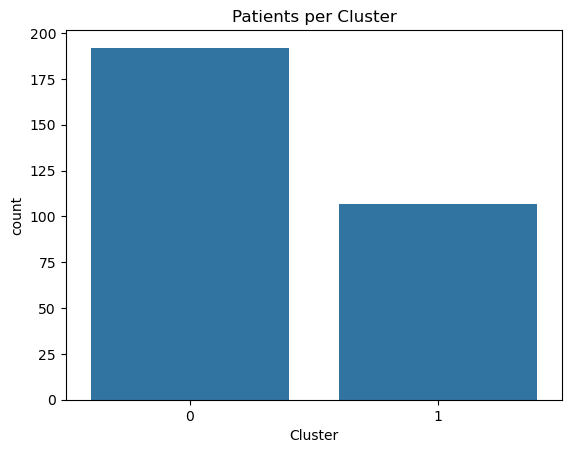

Cluster
0    192
1    107
Name: count, dtype: int64

In [117]:
sns.countplot(x='Cluster', data=df2)


plt.title("Patients per Cluster")

plt.show()
df2['Cluster'].value_counts()

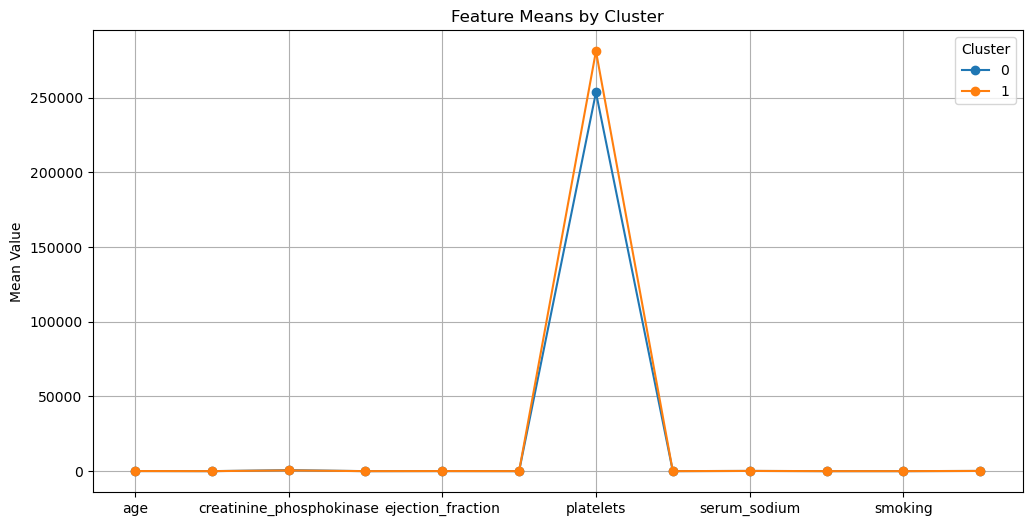

In [118]:
cluster_profile = df2.groupby('Cluster').mean(numeric_only=True)

cluster_profile.T.plot(
    figsize=(12,6),
    marker='o'
)

plt.ylabel("Mean Value")
plt.title("Feature Means by Cluster")
plt.grid(True)
plt.show()

In [119]:
df_summary = df2.copy()
df_summary['Cluster'] = kmeans.labels_

cluster_size = df_summary['Cluster'].value_counts().sort_index()

cluster_means = df_summary.groupby('Cluster')[numerical_cols].mean().round(2)

cat_counts = {}
for col in categorical_cols:
    counts = df_summary.groupby('Cluster')[col].value_counts().unstack(fill_value=0)
    counts.columns = [f'{col}_{c}' for c in counts.columns]
    cat_counts[col] = counts

cat_counts_df = pd.concat(cat_counts.values(), axis=1)

cluster_summary_full = pd.concat([cluster_means, cat_counts_df], axis=1)
cluster_summary_full.insert(0, 'Count', cluster_size)

cluster_summary_full

,Count,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia_0,anaemia_1,diabetes_0,diabetes_1,high_blood_pressure_0,high_blood_pressure_1,sex_0,sex_1,smoking_0,smoking_1
Cluster,,,,,,,,,,,,,,,,,
0,192,61.47,643.40,36.55,253473.07,1.40,136.52,116,76,124,68,133,59,0,192,100,92
1,107,59.69,471.38,40.83,281095.54,1.38,136.81,54,53,50,57,61,46,105,2,103,4


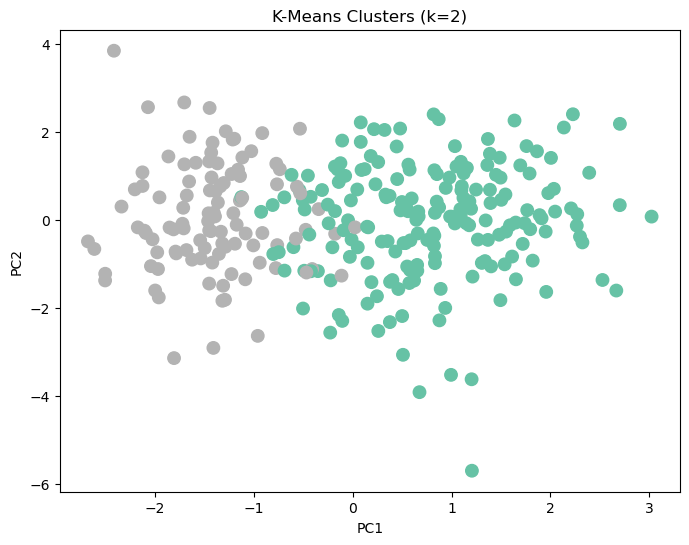

In [121]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df2['Cluster'],
    cmap='Set2',
    s=80
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (k=2)")
plt.show()

Average Silhouette Score: 0.118


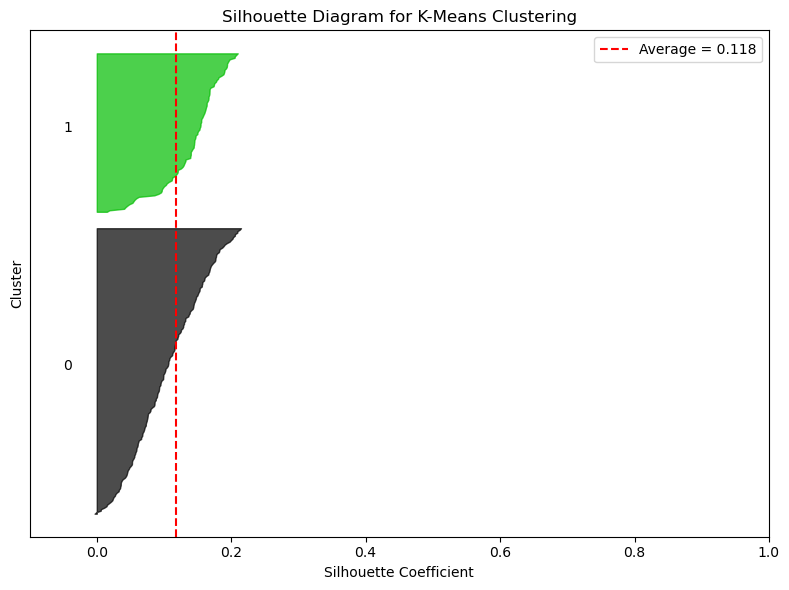

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

silhouette_avg = silhouette_score(X_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

print(f"Average Silhouette Score: {silhouette_avg:.3f}")

fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10

for i in range(k):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / k)

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10  # space between clusters

ax.set_title("Silhouette Diagram for K-Means Clustering")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")

ax.axvline(x=silhouette_avg, color="red", linestyle="--",
           label=f"Average = {silhouette_avg:.3f}")

ax.set_yticks([])
ax.set_xlim([-0.1, 1.0])
ax.legend()

plt.tight_layout()
plt.show()